### PART 1 — YOLOv5 Object Detection Code Explanation

In [2]:
#Step 1: Clone YOLOv5
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 17739, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 17739 (delta 57), reused 31 (delta 31), pack-reused 17643 (from 4)
Receiving objects: 100% (17739/17739), 17.16 MiB | 19.83 MiB/s, done.
Resolving deltas: 100% (12047/12047), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.5 MB/s eta 0:00:00


Explanation

!git clone ...
Downloads the official YOLOv5 repository from GitHub directly into Colab.

%cd yolov5
Moves into the YOLOv5 folder so Colab can run scripts from this directory.

!pip install -qr requirements.txt
Installs all required Python packages:

PyTorch

matplotlib

OpenCV

torchvision

etc.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
detect: weights=['yolov5s.pt'], source=zidane.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-448-gdeec5e45 Python-3.12.12 torch-2.8.0+cu126 CPU

100% 14.1M/14.1M [00:00<00:00, 45.9MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/1 /c

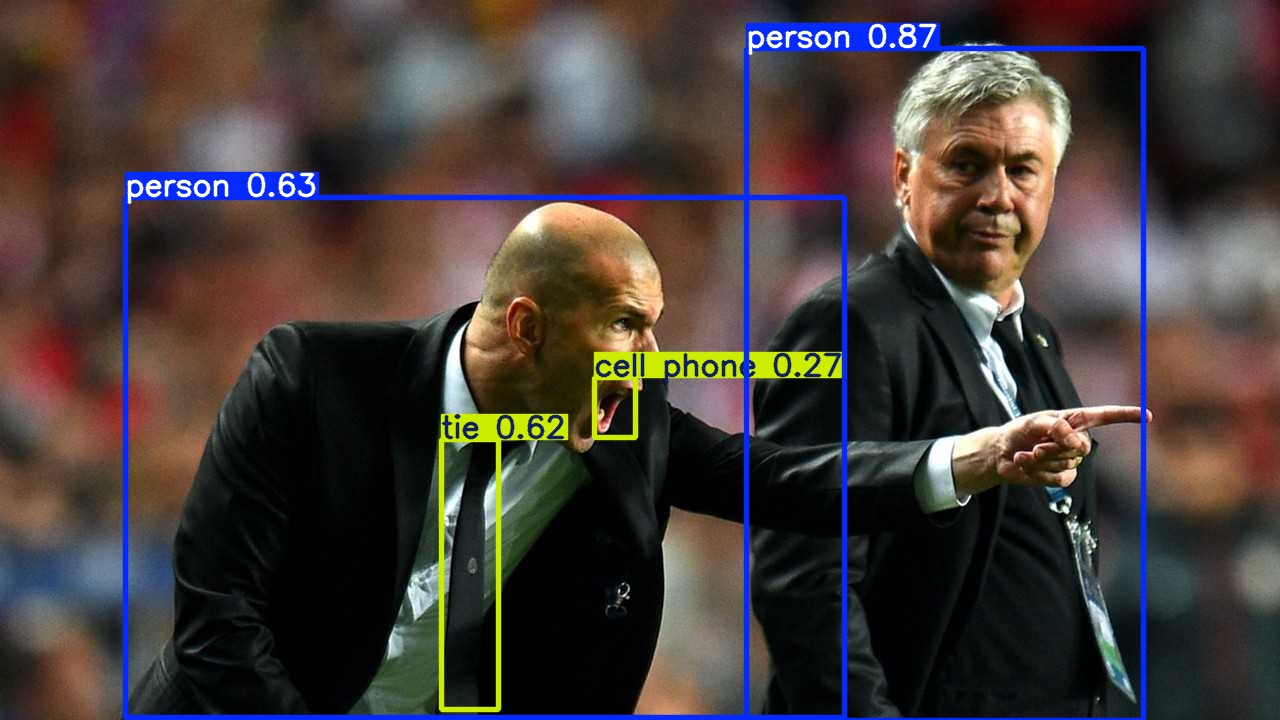

In [3]:
# Step 2: Test YOLOv5 on an Image
from IPython.display import Image

!wget -q https://ultralytics.com/images/zidane.jpg -O zidane.jpg
!python detect.py --source zidane.jpg --weights yolov5s.pt --conf 0.25

Image(filename='runs/detect/exp/zidane.jpg')


Explanation

wget
Downloads a sample test image.

python detect.py
Runs YOLO detection using the following parameters:

--source zidane.jpg → image to detect

--weights yolov5s.pt → pre-trained YOLOv5 small model

--conf 0.25 → confidence threshold (show predictions above 25% confidence)

The processed output image is saved to:  runs/detect/exp/zidane.jpg
Image(...)
Displays the detected image inside Colab

Step 3: Use YOLOv5 with Uploaded Images

In [4]:
from google.colab import files
uploaded = files.upload()

!python detect.py --source ./ --weights yolov5s.pt --conf 0.30


Saving photo-1539735257177-0d3949225f96.jpg to photo-1539735257177-0d3949225f96.jpg
detect: weights=['yolov5s.pt'], source=./, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.3, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-448-gdeec5e45 Python-3.12.12 torch-2.8.0+cu126 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
image 1/2 /content/yolov5/photo-1539735257177-0d3949225f96.jpg: 448x640 1 cup, 1 fork, 1 bowl, 6 broccolis, 3 carrots, 1 dining table, 321.5ms
image 2/2 /content/yolov5/zidane.jpg: 384x640 2 persons, 1 tie, 314.7ms
Speed: 0.9ms pre-process, 318.1ms inference, 1.6ms NMS per image at shape (

Latest folder: /content/yolov5/runs/detect/exp2


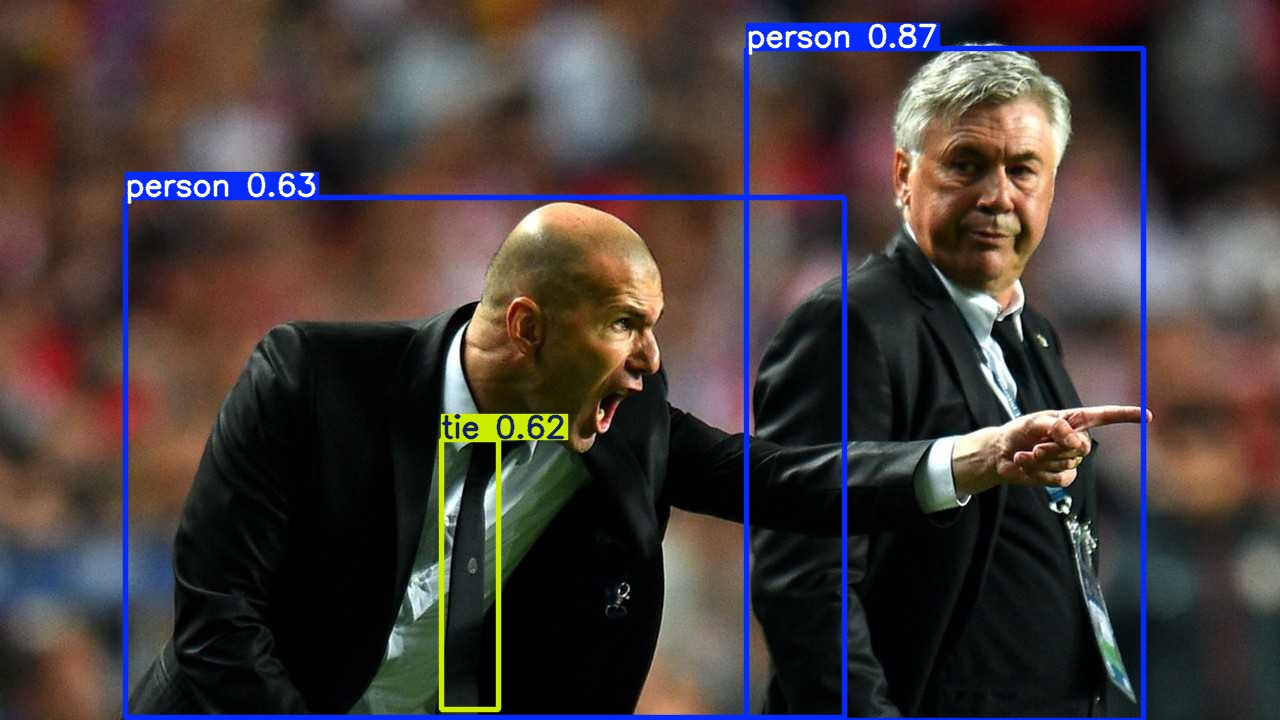

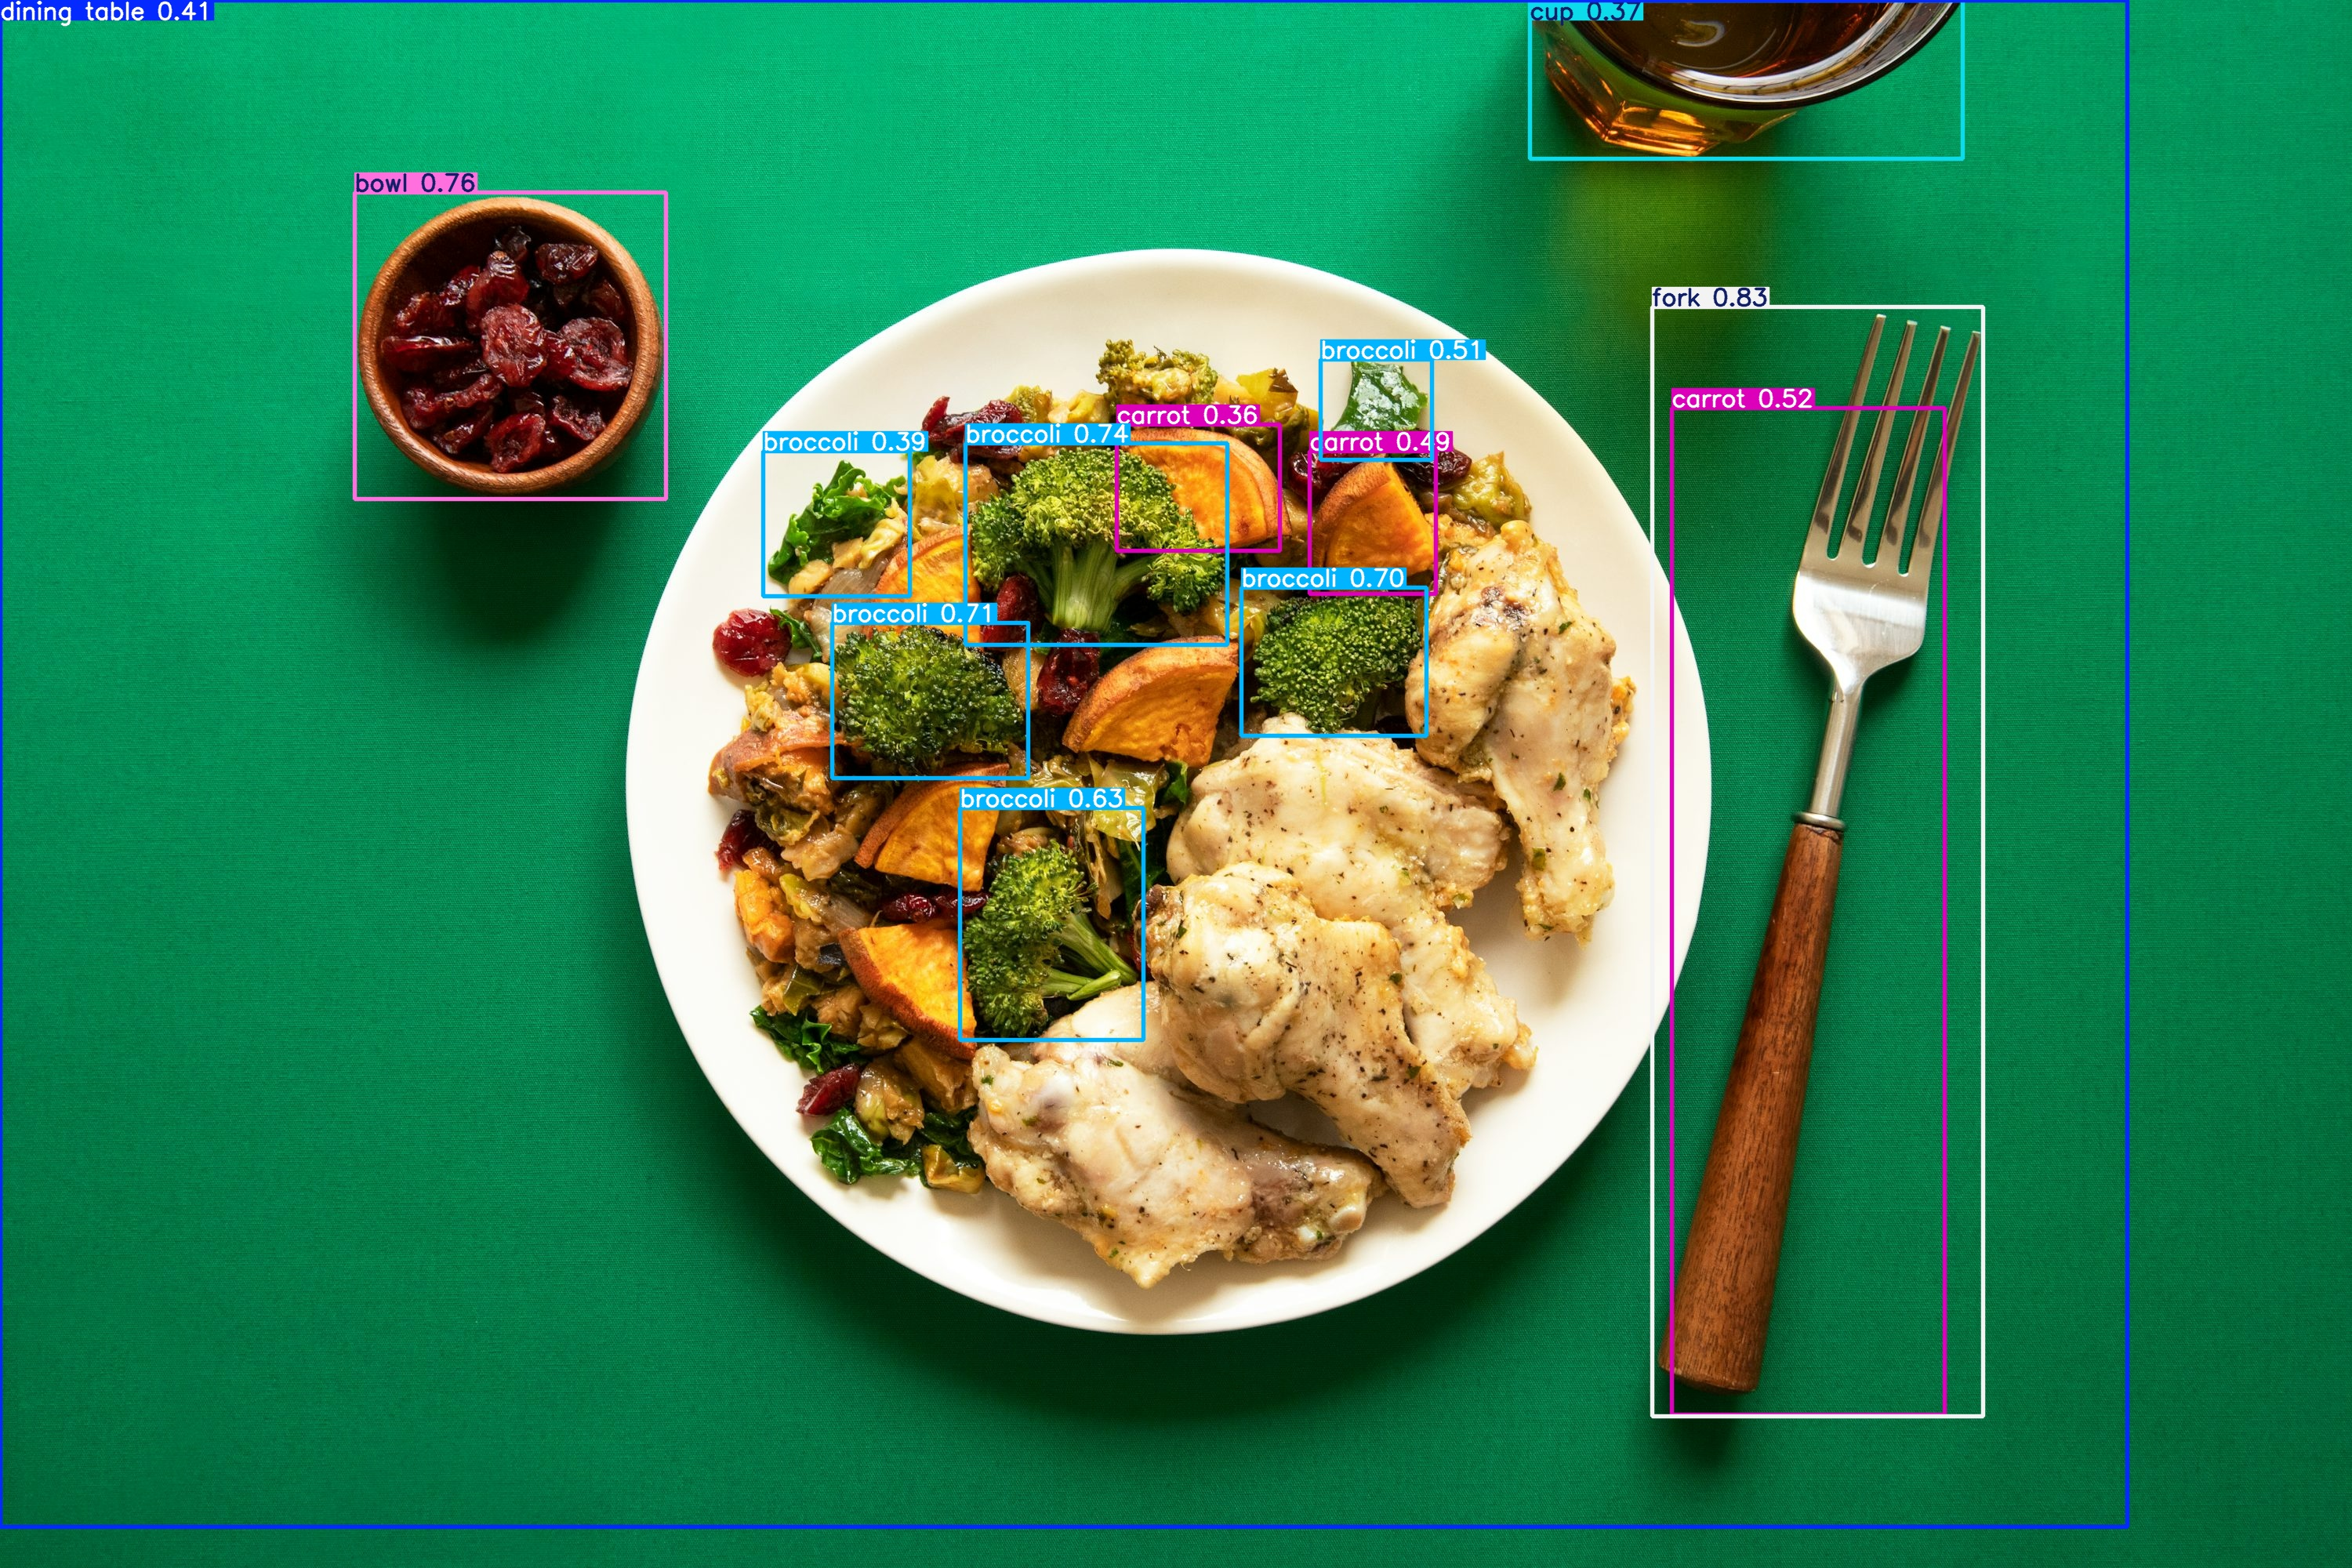

In [6]:
import glob
import os
from IPython.display import Image, display

# Get all exp folders inside detect/
exp_folders = sorted(glob.glob('/content/yolov5/runs/detect/exp*'), key=os.path.getmtime)

# The latest folder
latest_exp = exp_folders[-1]
print("Latest folder:", latest_exp)

# Display all images in the latest folder
for img_path in glob.glob(latest_exp + "/*.jpg"):
    display(Image(filename=img_path))


Explanation

files.upload()
Opens a file upload box → allows you to upload images from your computer.

--source ./
This tells YOLO to detect objects in all files in the current folder, including your uploaded images.

--conf 0.30
Increases confidence threshold to make predictions more accurate.

In [ ]:
# Step 4: Webcam Detection

!python detect.py --source 0 --weights yolov5s.pt


Explanation

--source 0
Uses your system’s webcam as input.

YOLO processes and shows live detection.

# PART 2 — SSD300 Object Detection Code Explanation

In [12]:
# Step 1: Install dependencies
!pip install torchvision matplotlib  # Installs: torchvision → gives access to pre-trained SSD model and matplotlib → used for showing images


In [8]:
# Step 2: Load SSD Model
import torch
import torchvision
from torchvision import transforms
import cv2
import matplotlib.pyplot as plt

model = torchvision.models.detection.ssd300_vgg16(pretrained=True)
model.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:03<00:00, 41.0MB/s]


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

Explanation

Imports PyTorch, TorchVision, OpenCV, and plotting tools.

ssd300_vgg16(pretrained=True)
Loads the SSD300 model pre-trained on COCO dataset.

model.eval()
Sets the model to evaluation mode (not training).

In [9]:
# Step 3: Preprocess Image
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((300, 300)),
    transforms.ToTensor()
])

image = cv2.imread("zidane.jpg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
inp = transform(rgb).unsqueeze(0)


Explanation

SSD requires input size 300×300, so we:

ToPILImage() → convert OpenCV image to PIL format

Resize(300,300) → SSD’s fixed input size

ToTensor() → convert image to PyTorch tensor

In [10]:
# Step 4: Run SSD Detection
with torch.no_grad():
    output = model(inp)[0]


Explanation

torch.no_grad()
Disables gradient computation → faster + reduces memory.

model(inp)
Runs SSD on the input image.

output contains:

scores → confidence scores

boxes → bounding box coordinates

labels → predicted classes

In [14]:
COCO_LABELS = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich",
    "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake",
    "chair", "couch", "potted plant", "bed", "dining table", "toilet",
    "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]


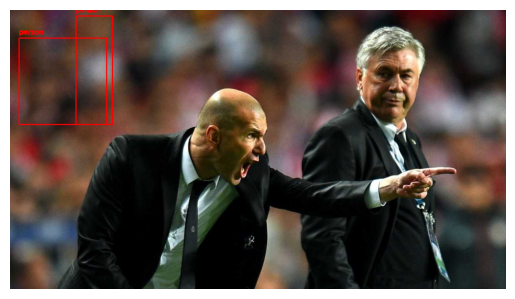

In [17]:
# Step 5: Draw Bounding Boxes

height, width, _ = rgb.shape

scores = output["scores"].detach().numpy()
boxes = output["boxes"].detach().numpy()
labels = output["labels"].detach().numpy()

for i in range(len(scores)):
    if scores[i] > 0.5:

        # SSD gives normalized coordinates → convert to pixels
        x1 = int(boxes[i][0] * width)
        y1 = int(boxes[i][1] * height)
        x2 = int(boxes[i][2] * width)
        y2 = int(boxes[i][3] * height)

        cv2.rectangle(rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)

        label = COCO_LABELS[labels[i]]
        cv2.putText(rgb, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255, 0, 0), 2)

plt.imshow(rgb)
plt.axis("off")
plt.show()


Explanation

Extract scores, labels, and bounding box coordinates.

Loop through all detections:

If score > 0.5 → draw box

cv2.rectangle draws rectangle around detected object

cv2.putText writes label name

Display final annotated image using matplotlib.

***Assignments:***

1. Parking Slot Detection System

Detect empty vs filled slots using YOLO.

2. Social Distancing Detector

Detect people + measure distance.

3. Helmet Detection System

Detect “person wearing helmet” vs “not wearing helmet”.